The human DLPFC data: [gene expression data](https://interactive.libd.org/spatialLIBD), [BAM files](https://research.libd.org/globus).

The loom files of unspliced and spliced counts was processed from the BAM files by [Velocyto](https://github.com/velocyto-team/velocyto.py).

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
data_path="../data/T1_Human_DLPFC_Visium_151676/"
adata=sc.read_loom(data_path+"151676_mRNA_TENIW.loom")
adata.obs.index = adata.obs.index.str.replace("151676_mRNA_TENIW:", "", regex=False)

In [3]:
adata_raw=sc.read_visium(data_path, count_file="filtered_feature_bc_matrix.h5")
Ann_df = pd.read_csv(data_path+'151676_truth.txt', sep='\t', header=None, index_col=0)
Ann_df.columns = ['Ground Truth']
adata_raw.obs['layer'] = Ann_df.loc[adata_raw.obs_names, 'Ground Truth']
adata_raw.obs['celltype'] = Ann_df.loc[adata_raw.obs_names, 'Ground Truth']
adata_raw.obsm['spatial'][:,1] = adata_raw.obsm['spatial'][:,1]*(-1)
adata_raw=adata_raw[adata_raw.obs['layer'].isna()==False]
adata_raw.obs.index = adata_raw.obs.index.str.replace("-1", "", regex=False)
adata_raw=adata_raw[adata_raw.obs_names.isin(adata.obs_names)]

In [4]:
label_df=adata_raw.obs
label_df=label_df[label_df.index.isin(adata.obs_names)]
adata=adata[label_df.index]
adata.obs.loc[label_df.index, label_df.columns]=label_df
adata.uns['spatial']=adata_raw.uns['spatial']
adata.obsm['spatial']=adata_raw.obsm['spatial']
adata.obsm['spatial'] = adata.obsm['spatial'].astype('float64')
adata.uns['layer_colors']=['#1f77b4', '#ff7f0e', '#49b192', '#d62728', '#aa40fc', '#8c564b', '#e377c2']
adata.uns['celltype_colors']=['#1f77b4', '#ff7f0e', '#49b192', '#d62728', '#aa40fc', '#8c564b', '#e377c2']

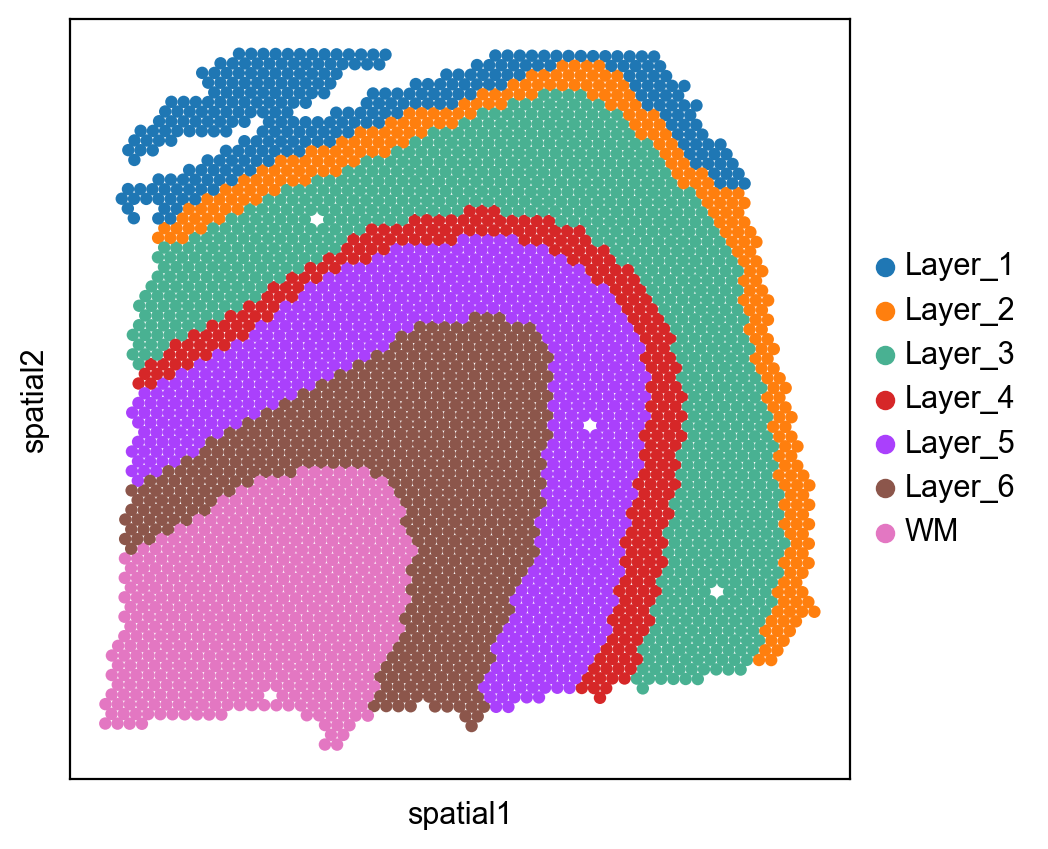

In [5]:
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.embedding(adata, basis="spatial", color="layer", title="", s=80)

# Run model

In [6]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced', 'ambiguous']: [0.08 0.81 0.11]


AnnData object with n_obs × n_vars = 3430 × 70116
    obs: 'in_tissue', 'array_row', 'array_col', 'layer', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'spatial', 'layer_colors', 'celltype_colors'
    obsm: 'spatial'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [7]:
stv.filter_and_normalize(adata, min_shared_counts=2, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 63675 genes that are detected 2 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:11) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [8]:
stv.Cal_Spatial_Net(adata, rad_cutoff=150)

------Calculating spatial graph...
The graph contains 19954 edges, 3430 cells.
5.8175 neighbors per cell on average.


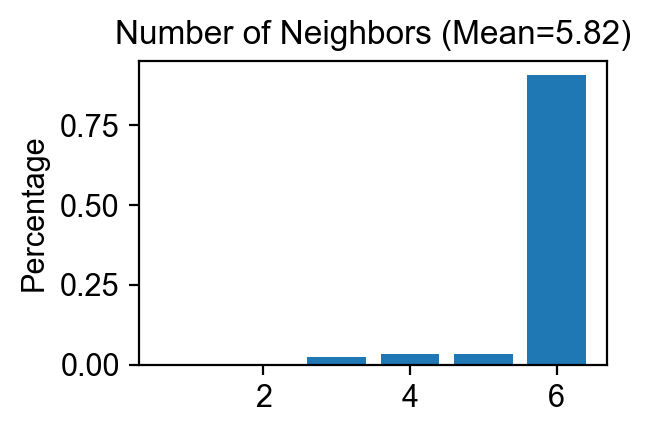

In [9]:
stv.Stats_Spatial_Net(adata)

In [10]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=1234, device = 'cuda:0')

Size of Input:  (3430, 1000)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 74.67it/s]


In [11]:
stv.velocity_graph(adata, n_neighbors=2000, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/3430 [00:00<?, ?cells/s]

    finished (0:00:11) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Velocity visualization

In [12]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


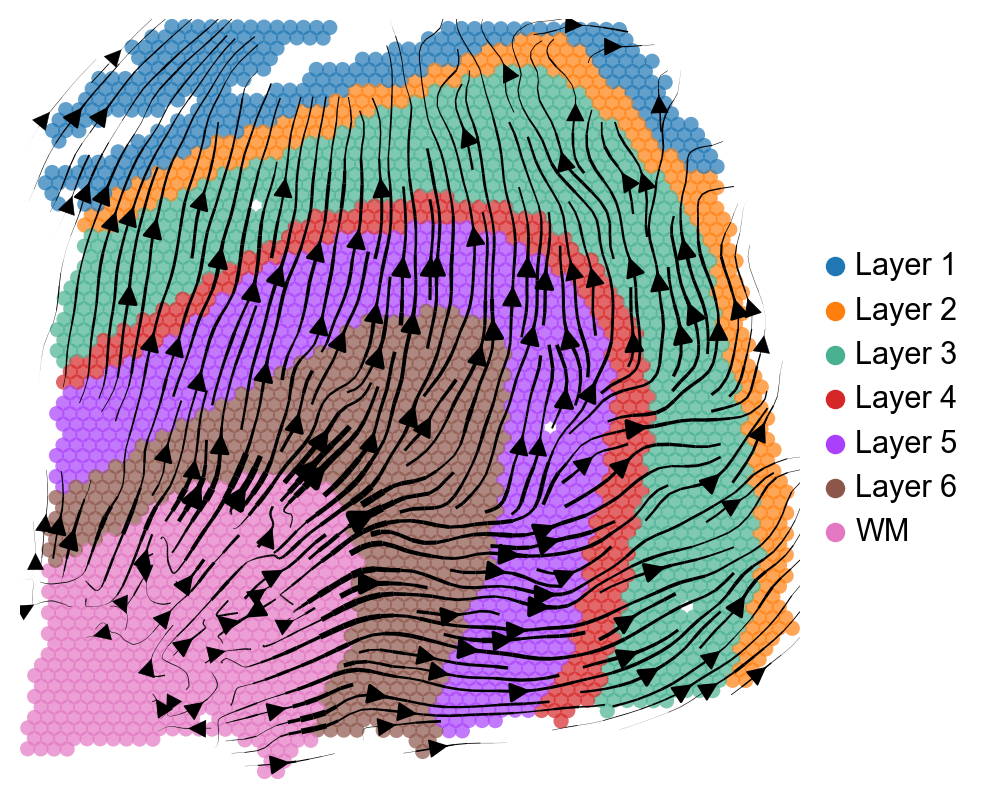

In [13]:
plt.rcParams["figure.figsize"] = (5, 5)
stv.velocity_embedding_stream(adata, basis='spatial', color="layer", title="", legend_loc="right", alpha=0.7, size=120, 
                              linewidth=1.5, arrow_size=1.5)

In [14]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")

# UMAP & PAGA

In [15]:
sc.pp.neighbors(adata, use_rep='rate')
sc.tl.umap(adata)
sc.tl.paga(adata, groups='layer')

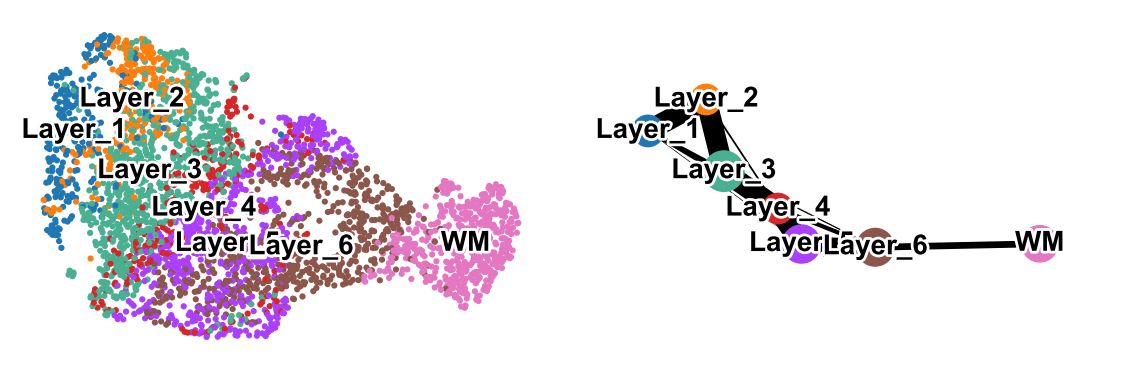

In [16]:
plt.rcParams["figure.figsize"] = (3.5,2)
sc.pl.paga_compare(adata, legend_fontsize=10, frameon=False, size=20, title="", legend_fontoutline=2)

# Pseudotime

In [17]:
adata.obs['spatial_xy'] = adata.obsm['spatial'][:, 0]+adata.obsm['spatial'][:, 1]
root_barcodes = adata.obs.nsmallest(10, 'spatial_xy').index
adata.obs['root'] = False
adata.obs.loc[root_barcodes, 'root'] = True
stv.latent_time(adata, vkey='velocity', root_key='root')

computing latent time using root as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)


(2830.15, 11626.85, -11579.7, -2214.3)

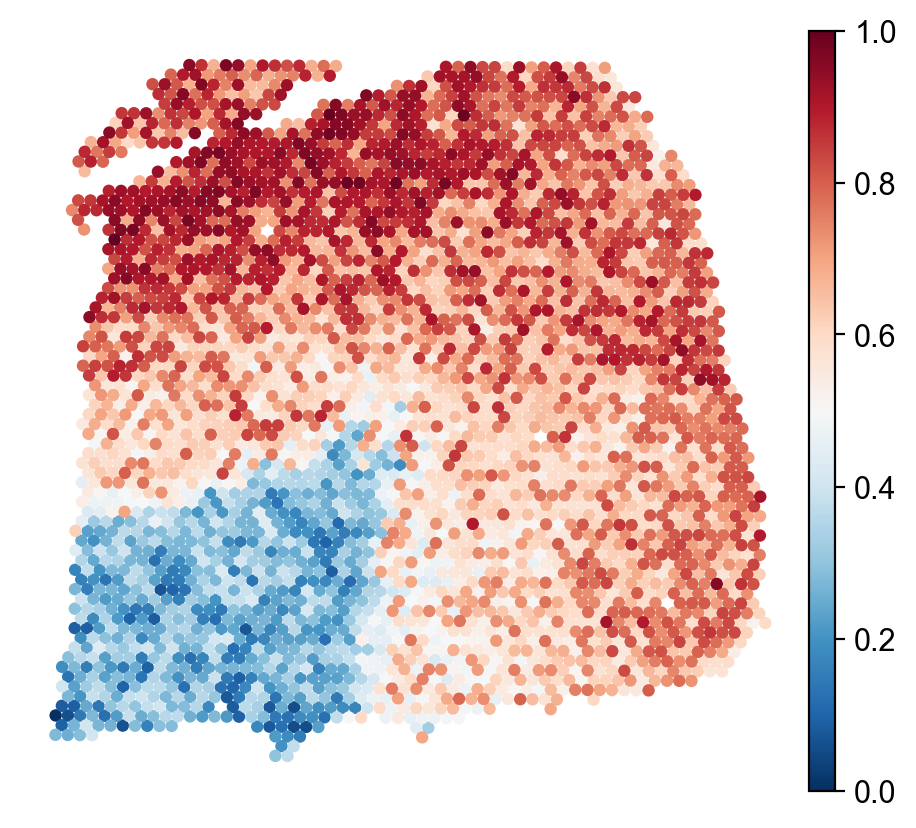

In [18]:
plt.rcParams["figure.figsize"] = (5.5, 5)
sc.pl.embedding(adata, basis="spatial", color="velocity_pseudotime", title="", s=80, show=False)
plt.axis('off')